In [1]:
import numpy as np
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise
import copy

from copy import deepcopy

from numpy import linalg

from scipy import signal
from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

audio_file = 'music.wav'

def read_file_PROPERLY(wavfile_name):
    samplerate_music, data_music = wavfile.read(wavfile_name) #Read the file
    data_music=data_music.astype(np.double)/2**15
    return samplerate_music,data_music

fs, data = read_file_PROPERLY(audio_file)#wavfile.read(audio_file)

Ls = len(data)

print('Setting up the frame parameters\n')


inputSDR = 7


wtype = 'hann'
w = 8192
a = int(w / 4)
M = 2*w

shrinkage = 'EW'
print('Setting up shrinkage operator: %s\n', shrinkage)

verbose = True


Setting up the frame parameters

Setting up shrinkage operator: %s
 EW


In [2]:
data

array([ 0.00549316, -0.0045166 , -0.01220703, ..., -0.04577637,
        0.00592041,  0.0428772 ])

In [3]:
ipd.Audio(data, rate=fs)

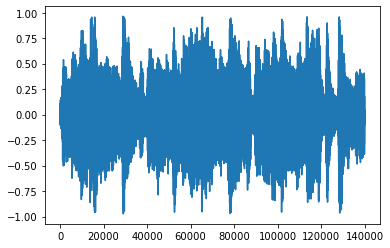

In [4]:
plt.plot(data)

In [5]:
def clip_audio(data, thresh):
    data = data.copy()
    masks = {}
    t_max = thresh
    t_min = -thresh
    mask_h  = data > t_max
    mask_l  = data < t_min
    mask_r = ~(mask_h | mask_l)
    masks['Mh'] = mask_h#(data > thresh)
    masks['Ml'] = mask_l#(data < -thresh)
    masks['Mr'] = mask_r#(data > thresh) | (data < -thresh)
#     data[masks['Mr']] = thresh
    data[mask_h] = t_max
    data[mask_l] = t_min
    return data, masks

In [6]:
theta = 0.1#15000

data_clipped, masks = clip_audio(data, theta)

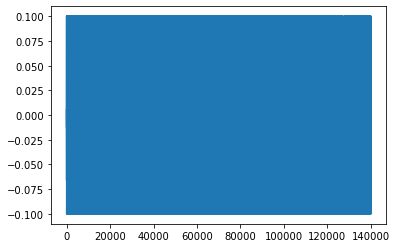

In [7]:
plt.plot(data_clipped)

In [8]:
ipd.Audio(data_clipped, rate=fs)

In [9]:
data_r = np.zeros((Ls,))
data_r[masks['Mr']] = data_clipped[masks['Mr']]

In [10]:
data_c = np.zeros(Ls)
data_c[masks['Mh']] = theta;
data_c[masks['Ml']] = -theta;

In [11]:
from ltfatpy.gabor.gabwin import gabwin
from ltfatpy.gabor.gabtight import gabtight
from ltfatpy.gabor.dgtreal import dgtreal
from ltfatpy.gabor.idgtreal import idgtreal

In [12]:

g = gabwin(g={'name': ('tight', 'hann')}, a=a, M=M)

# g = (g, {})

print(g)

data_clipped_float = data_clipped.astype('float64')

G_clip = dgtreal(data_clipped_float, g[0], a, M)
print(len(G_clip))
[nf,nt] = G_clip[0].shape


def analysis(x):
    return dgtreal(x,g[0],a,M)[0]
    
def synthesis(x):
    return idgtreal(x,g[0],a,M,Ls)[0]

(array([0.00451055, 0.00451055, 0.00451055, ..., 0.00451055, 0.00451055,
       0.00451055]), {'gauss': False, 'wasrow': False, 'isfir': True, 'istight': True, 'isdual': False, 'auxinfo': {'gauss': False, 'wasrow': False, 'isfir': True, 'istight': False, 'isdual': False, 'wasreal': True, 'gl': 16384}, 'wasreal': True, 'gl': 16384})
3


In [13]:
g

(array([0.00451055, 0.00451055, 0.00451055, ..., 0.00451055, 0.00451055,
        0.00451055]),
 {'gauss': False,
  'wasrow': False,
  'isfir': True,
  'istight': True,
  'isdual': False,
  'auxinfo': {'gauss': False,
   'wasrow': False,
   'isfir': True,
   'istight': False,
   'isdual': False,
   'wasreal': True,
   'gl': 16384},
  'wasreal': True,
  'gl': 16384})

In [14]:
# if shrinkage == 'L':
shrink = {'type':'l', 'lambda':1e-4, 'mu':1, 'glabel':'time','neigh':np.array([[1],[1]]), 'center':[1, 1], 'expo':1,'orth':0}
# elif shrinkage == 'WGL':
# shrink = {'type':'l', 'lambda':1e-4, 'mu':1, 'glabel':'time','neigh':np.ones((3,7)), 'center':[2,4], 'expo':1,'orth':0}
# elif shrinkage == 'EW':
# shrink = {'type': 'l', 'lambda': 1e-4, 'mu': 1, 'glabel': 'time','neigh': 1, 'center': [1, 1], 'expo': 2,'orth':0}
# elif shrinkage == 'PEW':
# shrink = {'type': 'l', 'lambda': 1e-4, 'mu': 1, 'glabel': 'time','neigh': np.ones((3,7)), 'center': [2,4], 'expo': 2,'orth':0}
# else:
#     error('Invalid shrinkage operator!')

In [15]:
# def maximum(x):
#     return max(0,x)

# def lasso_threshold(coeff,lambd):
#     first = lambd/abs(coeff)
#     maximun_v = np.vectorize(maximum)
#     second = maximun_v(first)
#     second=second.astype('complex128')
#     return second

In [16]:
z = np.arange(5)
z[0:4]

array([0, 1, 2, 3])

In [17]:
import math 

def sdr (u, v):

    sdr_val = 20*np.log10(np.linalg.norm(u)/np.linalg.norm(u-v))

    return sdr_val

def l_threshfunc(W, lama):
    threshfunc = lama/W
    return threshfunc
    
from scipy.signal import convolve2d

def conv2(x, y, mode='same'):
    return convolve2d(x, y, mode=mode)#np.rot90(convolve2d(np.rot90(x, 2), np.rot90(y, 2), mode=mode), 2)

def pers_weights(G, neigh, center):
    center = np.array([1,1])
    neigh = np.ones((1,1))
    M_,N = G.shape
    MM, NN = neigh.shape
    c1 = center[0]
    c2 = center[1]
    cc1 = int(np.ceil(MM/2))
    cc2 = int(np.ceil(NN/2))
    neigh = neigh/np.linalg.norm(neigh, ord=1) #norm(neigh(:),1);   ?

    X2 = np.zeros((M_+MM, N+NN))
    X2[c1:M_+c1, c2: N+c2] = np.abs(G)**2
    X2[:, :c2] =  np.fliplr(X2[:, c2:2*(c2)])
    X2[:, N+c2:] = np.fliplr(X2[:, N - NN +2*c2: N+c2])
    X2[:c1, :] = np.flipud(X2[c1:2*c1, :]) 
    X2[M_+c1:, :] = np.flipud(X2[M_-MM + 2*c1: M_+c1, :])
    X2 = convolve2d( X2, neigh, 'same')
    W = X2[cc1 : M_ + cc1, cc2 : N + cc2]
    W = np.sqrt(W)
    return W


def gen_thresh(G, shrink):
    # % computation of persistence weights
    W = pers_weights(G, shrink['neigh'], shrink['center'])

    # % computation of threshold function value
    TF = l_threshfunc(W, shrink['lambda'])#lasso_threshold(W, shrink['lambda'])#

    # % compute shrinkage
    TF[np.isinf(TF)] = 0
    Gs = 1 - np.power(TF, shrink['expo'])
    GGs = Gs*(Gs>0)
    
    
#     print(W.shape, Gs.shape, TF.shape, GGs.shape)
    Gs = G*GGs

    return Gs

In [18]:
from tqdm import tqdm
Gdeclip = np.zeros((nf,nt), dtype=np.complex128)
GdeclipZ = Gdeclip

number_lambdas = 5
inner_iterations = 500
delta = 1e-4
iter_cnt = 0

init_sdr = sdr(data, data_clipped)

# dSDR_process = np.empty(number_lambdas*inner_iterations)
# dSDR_process[:] = np.NaN
data_rec = data_clipped

for lamba in tqdm(np.logspace(-1,-4,number_lambdas)):
    shrink['lambda'] = lamba
    for k in range(inner_iterations):

        data_rec_old = data_rec.copy()
        iter_cnt = iter_cnt + 1

#         % forward step
        GdeclipOLD = Gdeclip.copy()
    
#         print(GdeclipZ)

        xdeclipZ = synthesis(GdeclipZ)
        
        if np.isnan(np.min(xdeclipZ)):
            raise Exception('np.isnan(np.min(xdeclipZ))')

        r1 = np.zeros(Ls)
#         print(xdeclipZ[masks['Mr']])
        r1[masks['Mr']] = data_r[masks['Mr']] - xdeclipZ[masks['Mr']]

        grad1 = -analysis(r1)

        r2 = np.zeros(Ls)
        r2[masks['Mh']] = data_c[masks['Mh']] - xdeclipZ[masks['Mh']]
        r2[masks['Ml']] = data_c[masks['Ml']] - xdeclipZ[masks['Ml']]

        r2[np.abs(xdeclipZ)>theta] = 0
        grad2 = -analysis(r2)


        GdeclipZ = GdeclipZ - grad1 - grad2
        
        if np.isnan(np.min(GdeclipZ)):
            raise Exception('GdeclipZ')
            

#         % thresholding step
        Gdeclip = gen_thresh(GdeclipZ, shrink) #lasso_threshold(GdeclipZ, lamba)#
        
        if np.isnan(np.min(GdeclipZ)):
            raise Exception('Gdeclip')

#         % relaxation step
        GdeclipZ = Gdeclip + (k-1)/(k+5) * (Gdeclip - GdeclipOLD)



        data_rec = synthesis(Gdeclip)
        
        if np.isnan(np.min(data_rec)):
            raise Exception('Gdeclip')
#         print(data_rec)
        dif = np.linalg.norm(data_rec_old - data_rec)
        if dif  < delta:
            break
        


        if verbose:
            sdr_rec = sdr(data, data_rec)
            print(sdr_rec, init_sdr, dif)
        

    


  0%|          | 0/5 [00:00<?, ?it/s]

1.510768095826266 3.050757044688279 21.18285173444689
1.563571051812929 3.050757044688279 0.7015337246987183
1.6312906686700384 3.050757044688279 0.7879839096240329
1.6751792284192548 3.050757044688279 0.5474062961334342
1.7069409440907335 3.050757044688279 0.43451728254352046
1.7318204226288245 3.050757044688279 0.3706583456695548
1.751267144812536 3.050757044688279 0.3148054445081948
1.7677272409239162 3.050757044688279 0.28841943949816395
1.7815154073788735 3.050757044688279 0.2616456394253328
1.7931929068576689 3.050757044688279 0.2421512969528783
1.8025607657037648 3.050757044688279 0.21054418264436972
1.8103499815892432 3.050757044688279 0.19524280589257065
1.8165329758858484 3.050757044688279 0.1809199173741365
1.8211853628898411 3.050757044688279 0.1619819009721613
1.8264361462537018 3.050757044688279 0.15797267724519248
1.8322448192198304 3.050757044688279 0.15884446204583585
1.8381443878529569 3.050757044688279 0.15488382899580178
1.8431989496201304 3.050757044688279 0.140373

  0%|          | 0/5 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [93]:
ipd.Audio(data_rec, rate=fs)

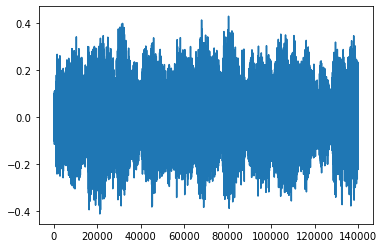

In [94]:
plt.plot(data_rec)

In [ ]:
plt.plot(data)